In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  0


In [ ]:
!pip install datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 12.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
!pip install transformers

**Snippet from assignment**

In [ ]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
from transformers import AutoTokenizer


# Load dataset
dataset = load_dataset('ag_news')

# Load model and tokenizer - FINE-TUNED
model_fineTuned = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Preprocess data
def preprocess_func(examples):
  return tokenizer(examples['text'], truncation=True, padding="max_length", max_length = 128)

encoded_dataset = dataset.map(preprocess_func, batched=True)
encoded_dataset = encoded_dataset.remove_columns(["text"])  # Keep only model-relevant columns
encoded_dataset = encoded_dataset.rename_column("label", "labels")


# Training arguments
training_args= TrainingArguments(
    output_dir = "./results",
    evaluation_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,
    per_device_train_batch_size = 16,
    num_train_epochs = 3
)

trainer = Trainer(
    model = model_fineTuned,
    args = training_args,
    train_dataset = encoded_dataset["train"],
    eval_dataset = encoded_dataset["test"]
)

# trainer.train()

# Save the fine-tuned model locally
# model_fineTuned.save_pretrained("./models/fine_tuned_model")

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
print(dataset["train"].column_names)

from collections import Counter

# Initialize an empty Counter
total_counts = Counter()

# Iterate through all splits in the dataset
for split in dataset:
    labels = dataset[split]["label"]
    total_counts.update(labels)

# Display results
for label, count in total_counts.items():
    print(f"Class {label}: {count} examples")


['text', 'label']
Class 2: 31900 examples
Class 3: 31900 examples
Class 1: 31900 examples
Class 0: 31900 examples


**3.4 - Extracting attention maps**

In [ ]:
# Snippet from hand-out, adapted

from transformers import BertTokenizer, BertModel
import torch
from transformers import AutoTokenizer


# Put models on the same device
# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_pretrained = BertModel.from_pretrained("bert-base-uncased",
                                             output_attentions=True)
tokenizer_pretrained = BertTokenizer.from_pretrained("bert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Example input
inputs_unseen1 = tokenizer("The Massachusetts Legislature approved a bill Monday aimed at closing loopholes in the state’s health care market regulatory process exposed by the collapse of Steward Health Care.", return_tensors="pt")

# Add attention output to model
model_fineTuned = BertForSequenceClassification.from_pretrained(
    "./models/fine_tuned_model",
    num_labels=4,
    output_attentions=True  # Enable attention outputs
)

# Move the models to the correct device
model_pretrained.to(device)
model_fineTuned.to(device)

# Move the inputs to the correct device
inputs_unseen1 = {key: value.to(device) for key, value in inputs_unseen1.items()}

# Get attentions
# Pre-trained
outputs1_pretrained = model_pretrained(**inputs_unseen1)
attentions1_pretrained = outputs1_pretrained.attentions
#Fine-tuned
outputs1_fineTuned = model_fineTuned(**inputs_unseen1)
attentions1_fineTuned = outputs1_fineTuned.attentions

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


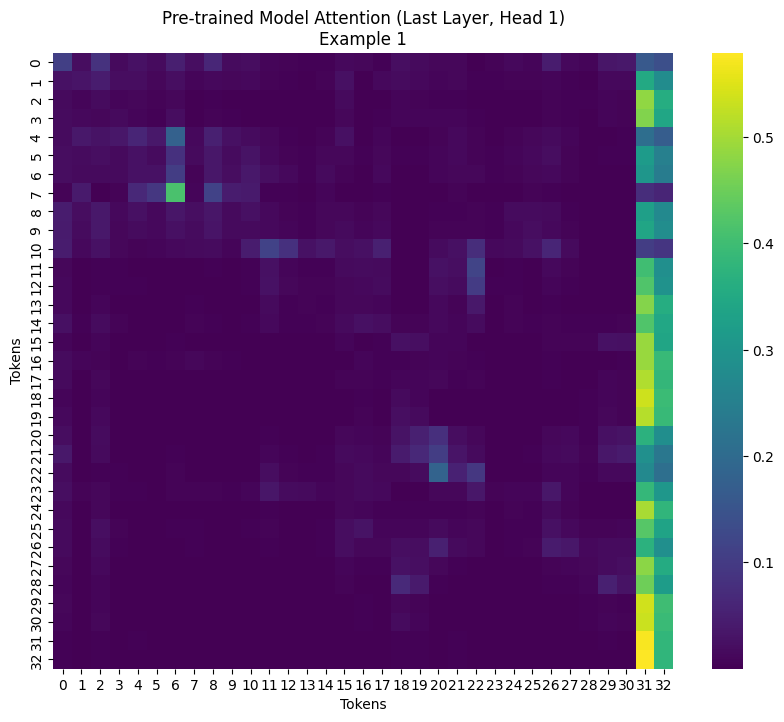

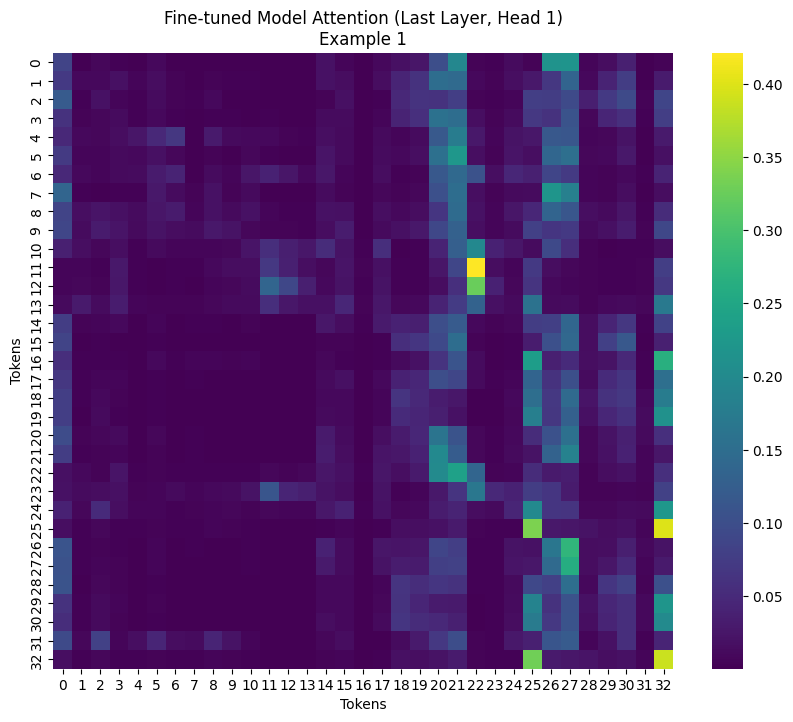

In [ ]:
# COMPARISON OF ATTENTION MAPS - VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

# Example: Visualize attention from the last layer, first head
def plot_attention(attention_map, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention_map[0][0].detach().cpu().numpy(), cmap="viridis")
    plt.title(title)
    plt.xlabel("Tokens")
    plt.ylabel("Tokens")
    plt.show()

# Pre-trained attention
plot_attention(attentions1_pretrained[-1],
               "Pre-trained Model Attention (Last Layer, Head 1)\nExample 1")

# Fine-tuned attention
plot_attention(attentions1_fineTuned[-1], "Fine-tuned Model Attention (Last Layer, Head 1)\nExample 1")


In [ ]:
# print(inputs_unseen1)
print(attentions1_fineTuned)

(tensor([[[[3.0007e-02, 4.0240e-02, 1.3771e-02,  ..., 1.5546e-02,
           3.3790e-02, 9.0735e-02],
          [4.5144e-02, 3.1350e-02, 3.3715e-02,  ..., 2.4188e-02,
           2.9548e-02, 2.7260e-02],
          [2.1620e-02, 1.5790e-02, 7.5840e-02,  ..., 2.4218e-02,
           1.3376e-02, 4.4803e-02],
          ...,
          [1.7193e-02, 3.2071e-02, 4.7200e-02,  ..., 1.1800e-02,
           3.4302e-02, 2.6527e-02],
          [2.0633e-02, 3.1194e-02, 2.3101e-02,  ..., 2.6917e-02,
           4.4840e-02, 2.1058e-02],
          [2.5098e-02, 4.8188e-02, 1.0235e-02,  ..., 2.4351e-02,
           5.7064e-02, 2.5860e-02]],

         [[4.8650e-01, 6.5397e-03, 1.9317e-03,  ..., 2.4255e-03,
           1.2039e-02, 2.4303e-03],
          [2.6399e-02, 3.3191e-02, 2.8920e-02,  ..., 2.4183e-02,
           3.8239e-02, 1.9340e-02],
          [5.3669e-03, 3.9824e-03, 8.8818e-03,  ..., 1.8707e-02,
           2.6798e-03, 9.8098e-03],
          ...,
          [8.3671e-03, 2.9476e-03, 2.3115e-02,  ..., 1.925